In [85]:
!pip install tensorflow

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import seaborn as sns
import pandas as pd

In [86]:
model = models.Sequential()
model.add(layers.Input(shape=(28, 28, 1)))
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

tensorboard_callback = tf.keras.callbacks.TensorBoard(logdir, histogram_freq=1)

In [87]:
#print (tf.__version__)
%reload_ext tensorboard
logdir='log'
(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()
train_images, train_images.reshape(60000, 28, 28, 1)
test_images = test_images.reshape(10000, 28, 28, 1)
train_images, test_images = train_images / 255.0, test_images / 255.0
classes=[0,1,2,3,4,5,6,7,8,9]

In [88]:
model = models.Sequential()
model.add(layers.Input(shape=(28, 28, 1)))
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

tensorboard_callback = tf.keras.callbacks.TensorBoard(logdir, histogram_freq=1)

In [89]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [90]:
model.fit(train_images, train_labels, epochs=4,
          validation_data=(test_images, test_labels),
          callbacks=[tensorboard_callback])

Epoch 1/4
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 41ms/step - accuracy: 0.9523 - loss: 0.1529 - val_accuracy: 0.9792 - val_loss: 0.0677
Epoch 2/4
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 66s 35ms/step - accuracy: 0.9854 - loss: 0.0463 - val_accuracy: 0.9882 - val_loss: 0.0356
Epoch 3/4
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 64s 34ms/step - accuracy: 0.9894 - loss: 0.0336 - val_accuracy: 0.9893 - val_loss: 0.0350
Epoch 4/4
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 34ms/step - accuracy: 0.9923 - loss: 0.0255 - val_accuracy: 0.9900 - val_loss: 0.0315


### Avaliar a acurácia final do modelo

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


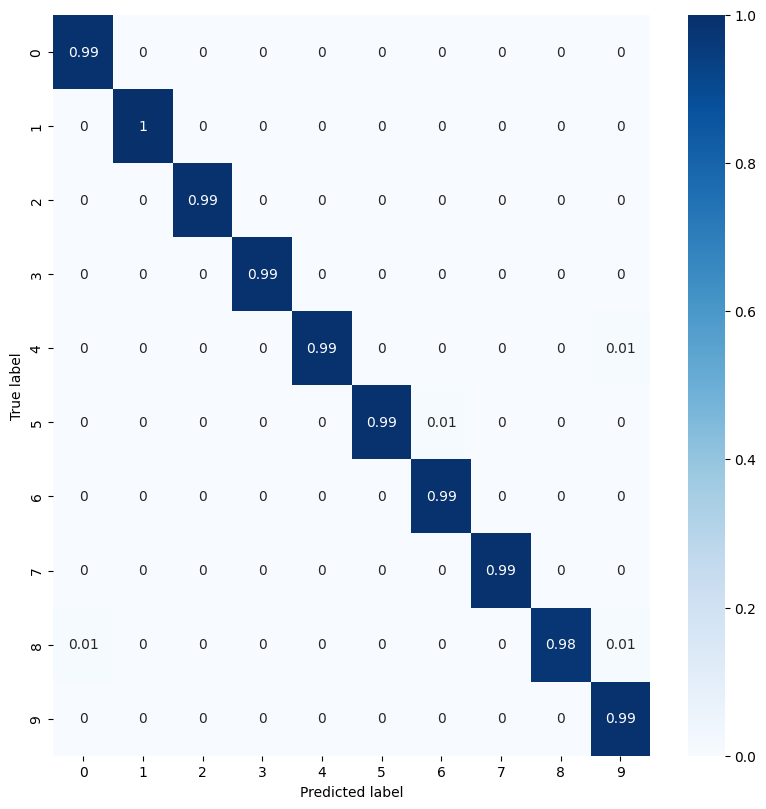

In [91]:
y_true=test_labels
y_pred=np.argmax(model.predict(test_images), axis=-1)

#classes=[0,1,2,3,4,5,6,7,8,9]

con_mat = tf.math.confusion_matrix(labels=y_true,predictions=y_pred).numpy()
con_mat_norm = np.around(con_mat.astype('float') / con_mat.sum(axis=1)[:, np.newaxis], decimals=2)

con_mat_df = pd.DataFrame(con_mat_norm,
                         index = classes,
                         columns = classes)

figure = plt.figure(figsize=(8, 8))
sns.heatmap(con_mat_df, annot=True,cmap=plt.cm.Blues)
plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()
#

### Cálculo de Métricas de Avaliação Detalhadas

In [95]:
class_idx = 0

VP = con_mat[class_idx, class_idx]
FP = np.sum(con_mat[:, class_idx]) - VP
FN = np.sum(con_mat[class_idx, :]) - VP
VN = np.sum(con_mat) - VP - FP - FN

print(f"Métricas para a Classe {class_idx}:")
print(f"Verdadeiros Positivos (VP): {VP}")
print(f"Falsos Positivos (FP): {FP}")
print(f"Falsos Negativos (FN): {FN}")
print(f"Verdadeiros Negativos (VN): {VN}")

if (VP + FN) > 0:
    sensibilidade = VP / (VP + FN)
else:
    sensibilidade = 0.0
print(f"Sensibilidade (Recall): {sensibilidade:.4f}")

if (VN + FP) > 0:
    especificidade = VN / (VN + FP)
else:
    especificidade = 0.0
print(f"Especificidade: {especificidade:.4f}")

if (VP + FP) > 0:
    precisao = VP / (VP + FP)
else:
    precisao = 0.0
print(f"Precisão: {precisao:.4f}")

if (precisao + sensibilidade) > 0:
    f_score = 2 * (precisao * sensibilidade) / (precisao + sensibilidade)
else:
    f_score = 0.0
print(f"F-score: {f_score:.4f}")


Métricas para a Classe 0:
Verdadeiros Positivos (VP): 975
Falsos Positivos (FP): 10
Falsos Negativos (FN): 5
Verdadeiros Negativos (VN): 9010
Sensibilidade (Recall): 0.9949
Especificidade: 0.9989
Precisão: 0.9898
F-score: 0.9924


In [93]:
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
print(f'Acurácia no conjunto de teste: {test_acc}')

313/313 - 8s - 25ms/step - accuracy: 0.9900 - loss: 0.0315
Acurácia no conjunto de teste: 0.9900000095367432
